In [1]:
# ============================================
# CELLULE 1 - INSTALLATION & IMPORTS
# ============================================

# Installer les librairies nécessaires
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn joblib -q

# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn pour classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("✅ Toutes les librairies sont importées")
print(f"✅ Scikit-learn version OK")

✅ Toutes les librairies sont importées
✅ Scikit-learn version OK


In [2]:
# ============================================
# CELLULE 2 - UPLOAD DES FICHIERS CSV
# ============================================

from google.colab import files
import io

print("="*60)
print("UPLOAD DES FICHIERS CSV")
print("="*60)
print("""
📤 Veuillez uploader les fichiers suivants :
   1. Dim_Client.csv
   2. Dim_Produits.csv
   3. Dim_Date.csv
   4. Dim_Commandes.csv
   5. Dim_Canal_Distribution.csv
   6. Fact_Vente.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)
""")

# Upload des fichiers
uploaded = files.upload()

print(f"\n✅ {len(uploaded)} fichiers uploadés avec succès !")
print(f"📁 Fichiers : {list(uploaded.keys())}")

# Charger les fichiers dans des dataframes
dfs = {}
for nom_fichier in uploaded.keys():
    nom_base = nom_fichier.replace('.csv', '').replace('.CSV', '')
    dfs[nom_base] = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
    print(f"   ✅ {nom_base} : {dfs[nom_base].shape[0]} lignes, {dfs[nom_base].shape[1]} colonnes")

# Assigner aux variables
df_client = dfs.get('Dim_Client')
df_produits = dfs.get('Dim_Produits')
df_date = dfs.get('Dim_Date')
df_commandes = dfs.get('Dim_Commandes')
df_canal = dfs.get('Dim_Canal_Distribution')
df_vente = dfs.get('Fact_Vente')

print("\n✅ Tous les fichiers sont chargés !")

UPLOAD DES FICHIERS CSV

📤 Veuillez uploader les fichiers suivants :
   1. Dim_Client.csv
   2. Dim_Produits.csv
   3. Dim_Date.csv
   4. Dim_Commandes.csv
   5. Dim_Canal_Distribution.csv
   6. Fact_Vente.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)



Saving Dim_Canal_Distribution.csv to Dim_Canal_Distribution.csv
Saving Dim_Client.csv to Dim_Client.csv
Saving Dim_Commandes.csv to Dim_Commandes.csv
Saving Dim_Date.csv to Dim_Date.csv
Saving Dim_Fournisseur.csv to Dim_Fournisseur.csv
Saving Dim_Matiere_Premiere.csv to Dim_Matiere_Premiere.csv
Saving Dim_Produits.csv to Dim_Produits.csv
Saving Dim_Reclamations.csv to Dim_Reclamations.csv
Saving Fact_Achat.csv to Fact_Achat.csv
Saving Fact_Vente.csv to Fact_Vente.csv

✅ 10 fichiers uploadés avec succès !
📁 Fichiers : ['Dim_Canal_Distribution.csv', 'Dim_Client.csv', 'Dim_Commandes.csv', 'Dim_Date.csv', 'Dim_Fournisseur.csv', 'Dim_Matiere_Premiere.csv', 'Dim_Produits.csv', 'Dim_Reclamations.csv', 'Fact_Achat.csv', 'Fact_Vente.csv']
   ✅ Dim_Canal_Distribution : 4 lignes, 6 colonnes
   ✅ Dim_Client : 446 lignes, 10 colonnes
   ✅ Dim_Commandes : 442 lignes, 8 colonnes
   ✅ Dim_Date : 1461 lignes, 12 colonnes
   ✅ Dim_Fournisseur : 67 lignes, 7 colonnes
   ✅ Dim_Matiere_Premiere : 62 lignes

In [3]:
# ============================================
# CELLULE 3 - CRÉATION DU DATASET
# ============================================

print("="*60)
print("CRÉATION DU DATASET POUR CLASSIFICATION")
print("="*60)

# Nettoyer les clés dans df_vente
for col in ['produit_key', 'client_key', 'date_key', 'commande_key', 'canal_key']:
    if col in df_vente.columns:
        df_vente[col] = df_vente[col].fillna(0).astype(int)

# Renommer les colonnes pour harmonisation
if 'Client_key' in df_client.columns:
    df_client = df_client.rename(columns={'Client_key': 'client_key'})
if 'Produit_key' in df_produits.columns:
    df_produits = df_produits.rename(columns={'Produit_key': 'produit_key'})
if 'Commande_key' in df_commandes.columns:
    df_commandes = df_commandes.rename(columns={'Commande_key': 'commande_key'})

# Jointures
df = df_vente.copy()
df = df.merge(df_client, on='client_key', how='left')
df = df.merge(df_produits, on='produit_key', how='left')
df = df.merge(df_date, on='date_key', how='left')
df = df.merge(df_commandes, on='commande_key', how='left')
df = df.merge(df_canal, on='canal_key', how='left')

print(f"✅ Dataset créé : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")

# Nettoyage initial
initial_rows = len(df)
df = df[df['produit_key'] != 0]
df = df[df['quantite'] > 0]
df = df[df['montant_ht'] > 0]
print(f"✅ Après nettoyage : {len(df):,} lignes (supprimé {initial_rows - len(df):,})")

# Gérer les valeurs manquantes
for col in ['Mode_paiement', 'Gouvernorat', 'Ville']:
    if col in df.columns:
        df[col] = df[col].fillna('Non renseigné')

for col in ['Frais_livraison', 'Remise_panier']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Nettoyer les montants avec virgule
def clean_float(x):
    if pd.isna(x):
        return 0.0
    if isinstance(x, str):
        try:
            return float(x.replace(',', '.'))
        except:
            return 0.0
    try:
        return float(x)
    except:
        return 0.0

for col in ['montant_ttc', 'montant_ht']:
    if col in df.columns:
        df[col] = df[col].apply(clean_float)

# CRÉATION DE LA CIBLE
if 'Statut_commande' in df.columns:
    df['est_terminee'] = (df['Statut_commande'] == 'Terminée').astype(int)
    print(f"\n🎯 Cible créée : 'est_terminee'")
    print(f"   Distribution :")
    print(f"      Terminées (1) : {df['est_terminee'].sum():,}")
    print(f"      Non terminées (0) : {(len(df) - df['est_terminee'].sum()):,}")
    print(f"      Pourcentage terminées : {df['est_terminee'].mean()*100:.1f}%")

print(f"\n✅ Dataset prêt : {df.shape}")

CRÉATION DU DATASET POUR CLASSIFICATION
✅ Dataset créé : 1,386 lignes, 55 colonnes
✅ Après nettoyage : 371 lignes (supprimé 1,015)

🎯 Cible créée : 'est_terminee'
   Distribution :
      Terminées (1) : 341
      Non terminées (0) : 30
      Pourcentage terminées : 91.9%

✅ Dataset prêt : (371, 56)


In [4]:
# ============================================
# CELLULE 4 - FEATURE ENGINEERING
# ============================================

print("="*60)
print("FEATURE ENGINEERING POUR CLASSIFICATION")
print("="*60)

# Variables temporelles
if 'date_complete' in df.columns:
    df['date_complete'] = pd.to_datetime(df['date_complete'], errors='coerce')
    df['jour_semaine'] = df['date_complete'].dt.dayofweek
    df['mois'] = df['date_complete'].dt.month
    print("   ✅ jour_semaine, mois créés")

# Variables financières
if 'montant_ht' in df.columns and 'quantite' in df.columns:
    df['prix_moyen_unitaire'] = df['montant_ht'] / df['quantite']
    print("   ✅ prix_moyen_unitaire créé")

if 'Frais_livraison' in df.columns and 'quantite' in df.columns:
    df['frais_livraison_par_produit'] = df['Frais_livraison'] / df['quantite']
    print("   ✅ frais_livraison_par_produit créé")

# Variables saisonnières
if 'est_ramadan' in df.columns:
    df['periode_ramadan'] = df['est_ramadan'].astype(int)
    print("   ✅ periode_ramadan créée")

if 'est_weekend' in df.columns:
    df['est_weekend_int'] = df['est_weekend'].astype(int)
    print("   ✅ est_weekend_int créé")

print(f"\n📊 Nombre total de colonnes : {len(df.columns)}")

FEATURE ENGINEERING POUR CLASSIFICATION
   ✅ jour_semaine, mois créés
   ✅ prix_moyen_unitaire créé
   ✅ frais_livraison_par_produit créé
   ✅ periode_ramadan créée
   ✅ est_weekend_int créé

📊 Nombre total de colonnes : 61


In [5]:
# ============================================
# CELLULE 5 - PRÉPARATION X ET y
# ============================================

print("="*60)
print("PRÉPARATION X ET y")
print("="*60)

# Sélectionner les features pour la classification
feature_cols = [
    'quantite',
    'montant_ht',
    'Frais_livraison',
    'prix_moyen_unitaire',
    'frais_livraison_par_produit',
    'jour_semaine',
    'mois',
    'periode_ramadan',
    'est_weekend_int'
]

# Ajouter les colonnes catégorielles encodées
categorical_cols = ['Mode_paiement', 'type_canal', 'physique_ou_digital']

# Garder uniquement les colonnes qui existent
feature_cols = [f for f in feature_cols if f in df.columns]
categorical_cols = [c for c in categorical_cols if c in df.columns]

print(f"Features numériques : {len(feature_cols)}")
print(f"   {feature_cols}")
print(f"Features catégorielles : {len(categorical_cols)}")
print(f"   {categorical_cols}")

# Préparer X et y
X = df[feature_cols + categorical_cols].copy()
y = df['est_terminee'].copy()

# Supprimer les lignes avec NaN dans y
X = X[y.notna()]
y = y[y.notna()]

print(f"\n📊 Dimensions finales :")
print(f"   X : {X.shape}")
print(f"   y : {y.shape}")
print(f"   Classes : {y.value_counts().to_dict()}")

PRÉPARATION X ET y
Features numériques : 9
   ['quantite', 'montant_ht', 'Frais_livraison', 'prix_moyen_unitaire', 'frais_livraison_par_produit', 'jour_semaine', 'mois', 'periode_ramadan', 'est_weekend_int']
Features catégorielles : 3
   ['Mode_paiement', 'type_canal', 'physique_ou_digital']

📊 Dimensions finales :
   X : (371, 12)
   y : (371,)
   Classes : {1: 341, 0: 30}


In [6]:
# ============================================
# CELLULE 6 - ENCODAGE
# ============================================

print("="*60)
print("ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*60)

from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding pour les variables catégorielles
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convertir en DataFrame
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

# Combiner avec les features numériques
X_final = pd.concat([X[feature_cols], X_encoded_df], axis=1)

print(f"✅ Encodage terminé")
print(f"   Features finales : {X_final.shape[1]} colonnes")
print(f"   {list(X_final.columns)}")

# Gérer les NaN restants
X_final = X_final.fillna(0)

print(f"\n✅ X_final prêt : {X_final.shape}")
print(f"   NaN restants : {X_final.isnull().sum().sum()}")

ENCODAGE DES VARIABLES CATÉGORIELLES
✅ Encodage terminé
   Features finales : 13 colonnes
   ['quantite', 'montant_ht', 'Frais_livraison', 'prix_moyen_unitaire', 'frais_livraison_par_produit', 'jour_semaine', 'mois', 'periode_ramadan', 'est_weekend_int', 'Mode_paiement_Pay in Person', 'Mode_paiement_Paymee', 'Mode_paiement_Wallet payment', 'type_canal_B2C']

✅ X_final prêt : (371, 13)
   NaN restants : 0


In [7]:
# ============================================
# CELLULE 7 - TRAIN/TEST SPLIT ET IMBALANCE
# ============================================

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Split terminé :")
print(f"   Train : {X_train.shape[0]} lignes")
print(f"   Test : {X_test.shape[0]} lignes")
print(f"\n   Distribution y_train :")
print(f"      Classe 0 : {(y_train == 0).sum()}")
print(f"      Classe 1 : {(y_train == 1).sum()}")
print(f"\n   Distribution y_test :")
print(f"      Classe 0 : {(y_test == 0).sum()}")
print(f"      Classe 1 : {(y_test == 1).sum()}")

# Vérifier le déséquilibre
class_ratio = (y_train == 1).sum() / len(y_train)
print(f"\n⚠️ Ratio classe 1 (terminée) : {class_ratio*100:.1f}%")

if class_ratio < 0.3 or class_ratio > 0.7:
    print(f"   → Déséquilibre détecté ! Utilisation de SMOTE")
    use_smote = True
else:
    print(f"   → Données équilibrées, pas de SMOTE nécessaire")
    use_smote = False

TRAIN/TEST SPLIT
📊 Split terminé :
   Train : 296 lignes
   Test : 75 lignes

   Distribution y_train :
      Classe 0 : 24
      Classe 1 : 272

   Distribution y_test :
      Classe 0 : 6
      Classe 1 : 69

⚠️ Ratio classe 1 (terminée) : 91.9%
   → Déséquilibre détecté ! Utilisation de SMOTE


In [8]:
# ============================================
# CELLULE 8 - MODÈLE 1 : LOGISTIC REGRESSION
# ============================================

print("="*60)
print("MODÈLE 1 : LOGISTIC REGRESSION")
print("="*60)

from sklearn.preprocessing import StandardScaler

# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Définir les paramètres pour GridSearch
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': ['balanced', None]
}

# Initialiser le modèle
lr = LogisticRegression(random_state=42, max_iter=1000)

# GridSearch avec cross-validation
grid_lr = GridSearchCV(
    lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=1
)

print("🔍 Recherche des meilleurs hyperparamètres...")
grid_lr.fit(X_train_scaled, y_train)

print(f"\n✅ Meilleurs paramètres : {grid_lr.best_params_}")
print(f"   Meilleur score F1 (CV) : {grid_lr.best_score_:.4f}")

# Meilleur modèle
best_lr = grid_lr.best_estimator_

# Prédictions
y_pred_lr = best_lr.predict(X_test_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

# Métriques
print(f"\n📊 PERFORMANCES SUR LE TEST :")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"   Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"   Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"   F1-Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print(f"\n📋 Classification Report :")
print(classification_report(y_test, y_pred_lr))

MODÈLE 1 : LOGISTIC REGRESSION
🔍 Recherche des meilleurs hyperparamètres...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Meilleurs paramètres : {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
   Meilleur score F1 (CV) : 0.9832

📊 PERFORMANCES SUR LE TEST :
   Accuracy  : 0.9733
   Precision : 1.0000
   Recall    : 0.9710
   F1-Score  : 0.9853
   ROC-AUC   : 0.9891

📋 Classification Report :
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      0.97      0.99        69

    accuracy                           0.97        75
   macro avg       0.88      0.99      0.92        75
weighted avg       0.98      0.97      0.98        75



VISUALISATIONS - LOGISTIC REGRESSION


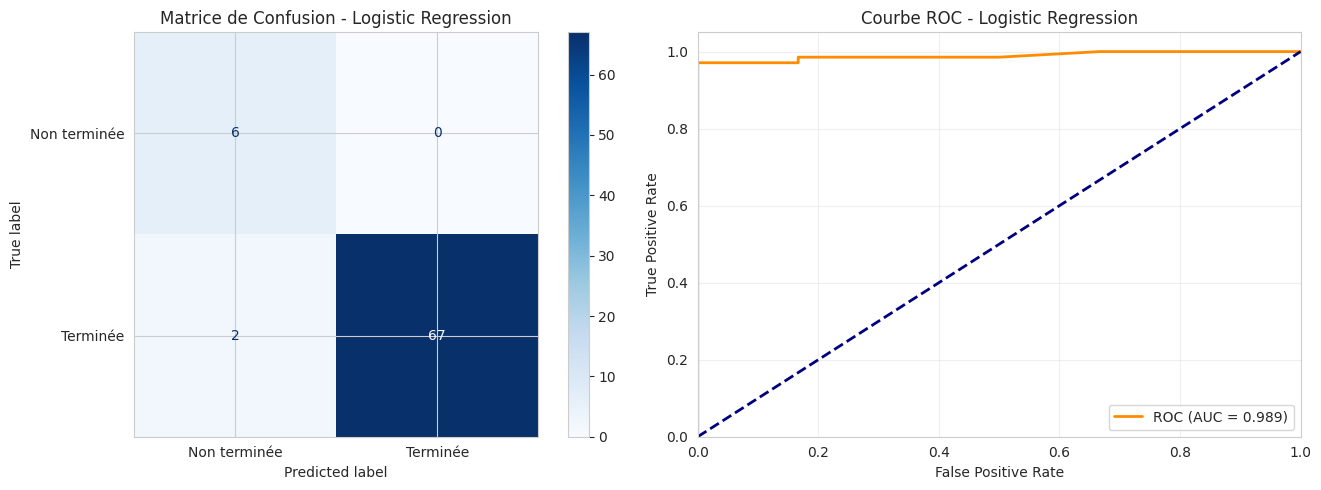

✅ Visualisations terminées


In [9]:
# ============================================
# CELLULE 9 - VISUALISATIONS LOGISTIC REGRESSION
# ============================================

print("="*60)
print("VISUALISATIONS - LOGISTIC REGRESSION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non terminée', 'Terminée'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matrice de Confusion - Logistic Regression')

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lr)
auc = roc_auc_score(y_test, y_pred_proba_lr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC - Logistic Regression')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualisations terminées")

FEATURE IMPORTANCE - LOGISTIC REGRESSION
Top 10 features les plus influentes :
                     feature  coefficient  abs_coefficient
                        mois   -18.398074        18.398074
         prix_moyen_unitaire    -1.346747         1.346747
                  montant_ht    -1.328236         1.328236
              type_canal_B2C     1.274394         1.274394
                    quantite    -1.271601         1.271601
             periode_ramadan    -0.860399         0.860399
 frais_livraison_par_produit    -0.503805         0.503805
Mode_paiement_Wallet payment     0.224623         0.224623
                jour_semaine     0.172495         0.172495
             est_weekend_int    -0.164757         0.164757


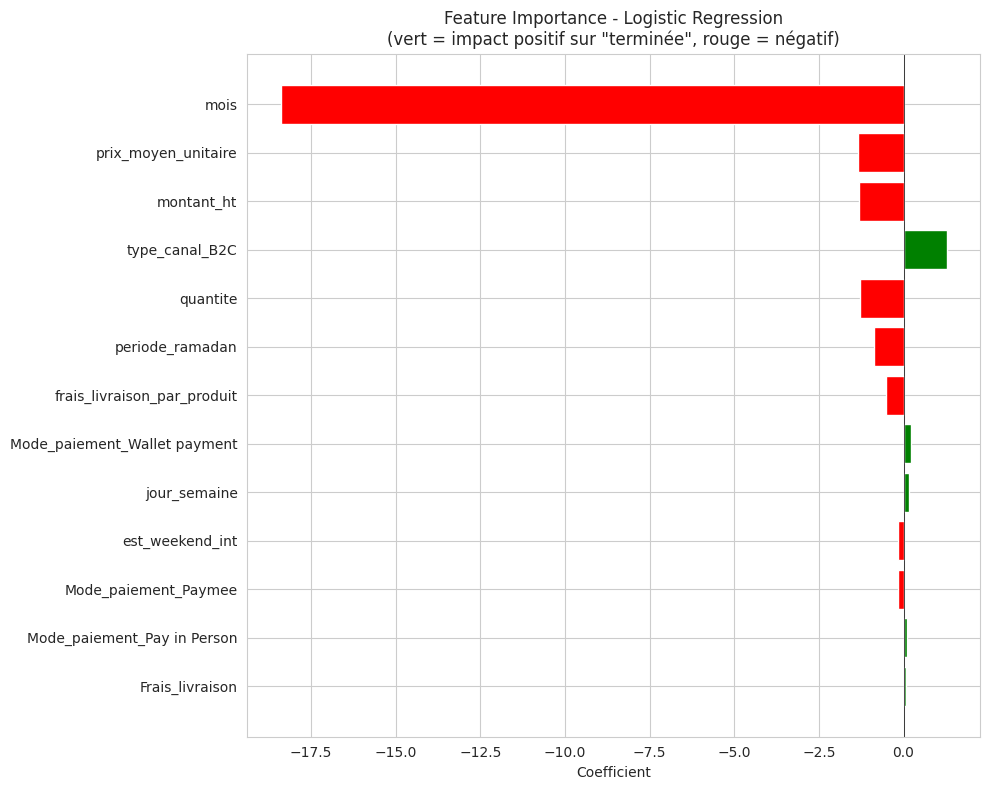


📝 Interprétation :
   - Coefficient positif → augmente la probabilité que la commande soit terminée
   - Coefficient négatif → diminue la probabilité


In [10]:
# ============================================
# CELLULE 10 - FEATURE IMPORTANCE
# Logistic Regression (coefficients)
# ============================================

print("="*60)
print("FEATURE IMPORTANCE - LOGISTIC REGRESSION")
print("="*60)

# Récupérer les coefficients
coefficients = best_lr.coef_[0]
feature_names = X_final.columns

# Créer DataFrame des importances
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Top 10 features les plus influentes :")
print(importance_df.head(10).to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
colors = ['red' if c < 0 else 'green' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient')
plt.title('Feature Importance - Logistic Regression\n(vert = impact positif sur "terminée", rouge = négatif)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📝 Interprétation :")
print("   - Coefficient positif → augmente la probabilité que la commande soit terminée")
print("   - Coefficient négatif → diminue la probabilité")

In [11]:
# ============================================
# CELLULE 11 - MODÈLE 2 : RANDOM FOREST
# ============================================

print("="*60)
print("MODÈLE 2 : RANDOM FOREST")
print("="*60)

# Définir les paramètres pour GridSearch
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

# Initialiser le modèle
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearch avec cross-validation (réduit pour le temps)
print("🔍 Recherche des meilleurs hyperparamètres...")
print("   (Cela peut prendre quelques minutes)")

grid_rf = GridSearchCV(
    rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)  # Random Forest n'a pas besoin de scaling

print(f"\n✅ Meilleurs paramètres : {grid_rf.best_params_}")
print(f"   Meilleur score F1 (CV) : {grid_rf.best_score_:.4f}")

# Meilleur modèle
best_rf = grid_rf.best_estimator_

# Prédictions
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# Métriques
print(f"\n📊 PERFORMANCES SUR LE TEST :")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"   Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"   F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print(f"\n📋 Classification Report :")
print(classification_report(y_test, y_pred_rf))

MODÈLE 2 : RANDOM FOREST
🔍 Recherche des meilleurs hyperparamètres...
   (Cela peut prendre quelques minutes)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Meilleurs paramètres : {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
   Meilleur score F1 (CV) : 0.9833

📊 PERFORMANCES SUR LE TEST :
   Accuracy  : 0.9733
   Precision : 0.9855
   Recall    : 0.9855
   F1-Score  : 0.9855
   ROC-AUC   : 0.9867

📋 Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.99      0.99      0.99        69

    accuracy                           0.97        75
   macro avg       0.91      0.91      0.91        75
weighted avg       0.97      0.97      0.97        75



VISUALISATIONS - RANDOM FOREST


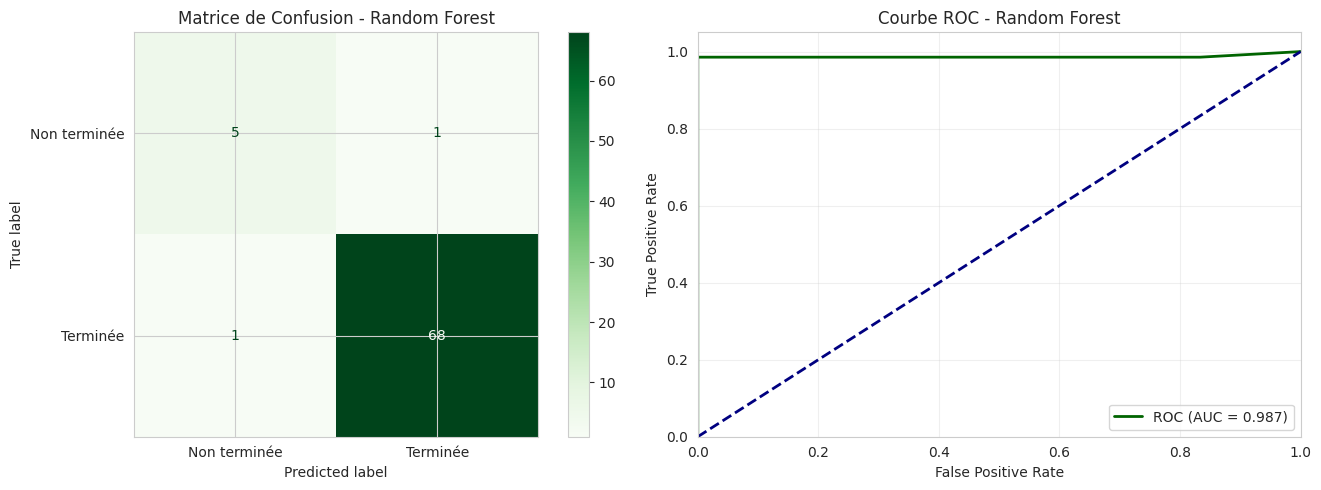

✅ Visualisations terminées


In [12]:
# ============================================
# CELLULE 12 - VISUALISATIONS RANDOM FOREST
# ============================================

print("="*60)
print("VISUALISATIONS - RANDOM FOREST")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non terminée', 'Terminée'])
disp.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title('Matrice de Confusion - Random Forest')

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
auc = roc_auc_score(y_test, y_pred_proba_rf)
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC - Random Forest')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualisations terminées")

FEATURE IMPORTANCE - RANDOM FOREST
Top 15 features les plus importantes :
                     feature  importance
                        mois    0.644473
         prix_moyen_unitaire    0.101979
                  montant_ht    0.099668
                jour_semaine    0.039330
              type_canal_B2C    0.022283
 frais_livraison_par_produit    0.021701
Mode_paiement_Wallet payment    0.019069
 Mode_paiement_Pay in Person    0.015427
             Frais_livraison    0.012553
                    quantite    0.010097
             est_weekend_int    0.008654
             periode_ramadan    0.004642
        Mode_paiement_Paymee    0.000125


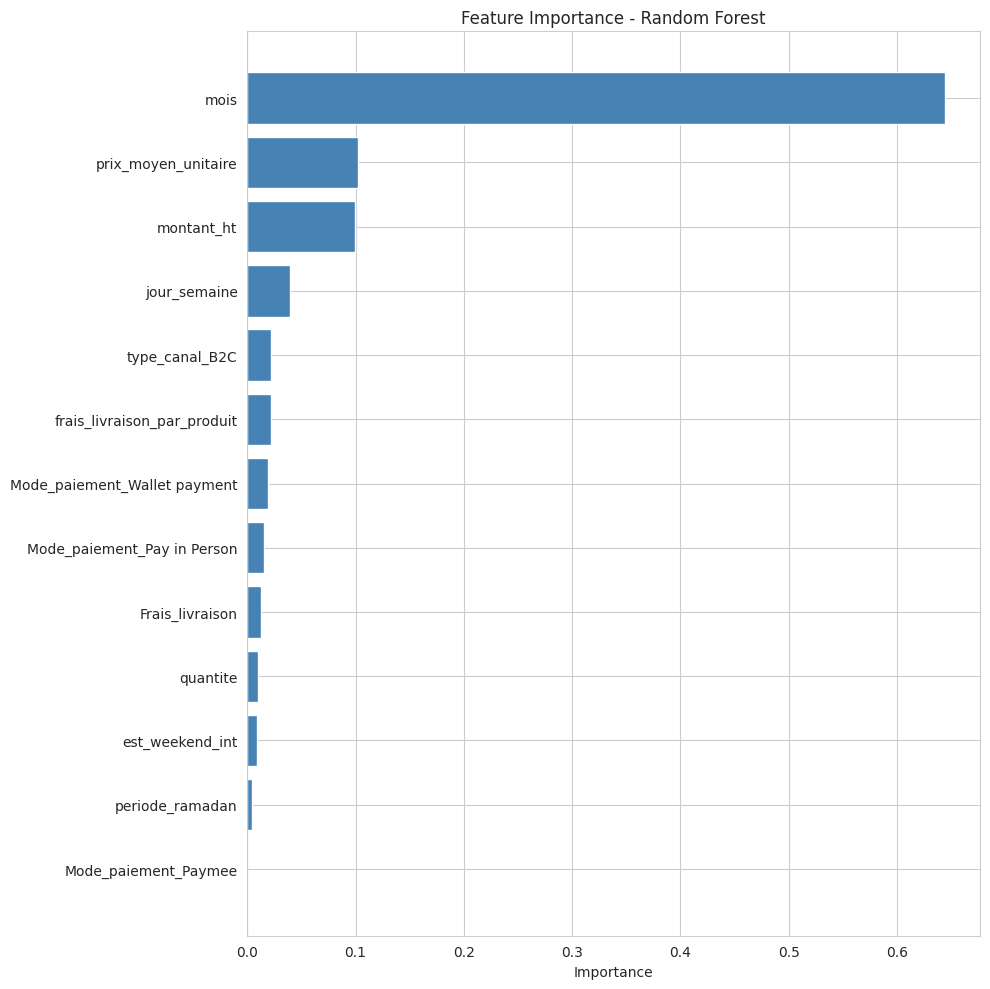


📝 Interprétation :
   - Plus l'importance est élevée, plus la feature influence la prédiction
   - Les 3 features les plus importantes sont essentielles pour le modèle


In [13]:
# ============================================
# CELLULE 13 - FEATURE IMPORTANCE
# Random Forest
# ============================================

print("="*60)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("="*60)

# Récupérer les importances
importances = best_rf.feature_importances_
feature_names = X_final.columns

# Créer DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 features les plus importantes :")
print(importance_df.head(15).to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 10))
top_features = importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📝 Interprétation :")
print("   - Plus l'importance est élevée, plus la feature influence la prédiction")
print("   - Les 3 features les plus importantes sont essentielles pour le modèle")

COMPARAISON LOGISTIC REGRESSION vs RANDOM FOREST
             Modèle  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9733     1.0000  0.9710    0.9853   0.9891
      Random Forest    0.9733     0.9855  0.9855    0.9855   0.9867


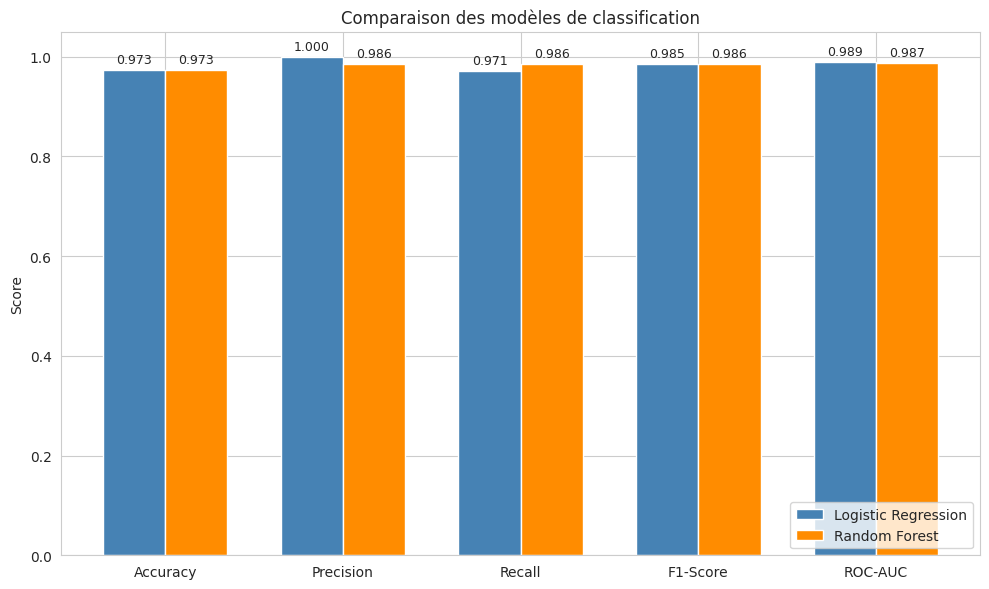

In [14]:
# ============================================
# CELLULE 14 - COMPARAISON DES MODÈLES
# ============================================

print("="*60)
print("COMPARAISON LOGISTIC REGRESSION vs RANDOM FOREST")
print("="*60)

# Créer DataFrame de comparaison
comparison = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_proba_lr), roc_auc_score(y_test, y_pred_proba_rf)]
})

print(comparison.round(4).to_string(index=False))

# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

lr_scores = [comparison.iloc[0][m] for m in metrics]
rf_scores = [comparison.iloc[1][m] for m in metrics]

bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles de classification')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

# Ajouter les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

COMPARAISON DES COURBES ROC


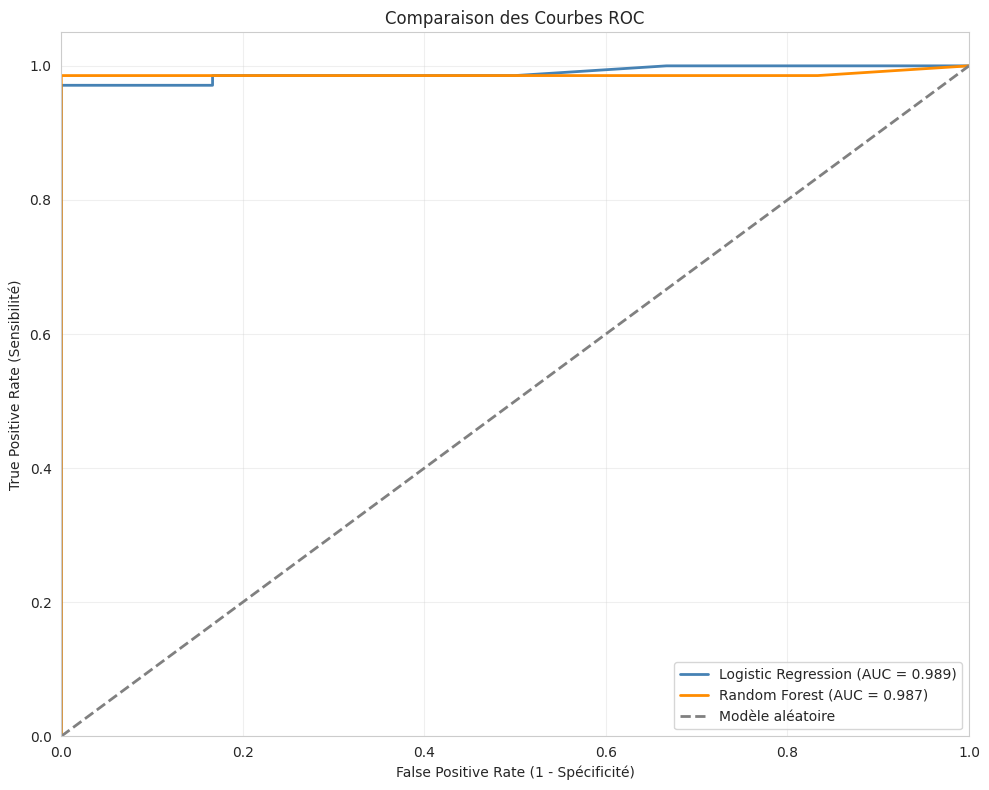


📝 Interprétation :
   - Plus l'AUC est proche de 1, meilleur est le modèle
   - Logistic Regression AUC : 0.989
   - Random Forest AUC : 0.987
   → Logistic Regression a de meilleures performances globales


In [15]:
# ============================================
# CELLULE 15 - COMPARAISON DES COURBES ROC
# ============================================

print("="*60)
print("COMPARAISON DES COURBES ROC")
print("="*60)

plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')

# Baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Modèle aléatoire')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Spécificité)')
plt.ylabel('True Positive Rate (Sensibilité)')
plt.title('Comparaison des Courbes ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📝 Interprétation :")
print("   - Plus l'AUC est proche de 1, meilleur est le modèle")
print("   - Logistic Regression AUC : {:.3f}".format(auc_lr))
print("   - Random Forest AUC : {:.3f}".format(auc_rf))
if auc_rf > auc_lr:
    print("   → Random Forest a de meilleures performances globales")
else:
    print("   → Logistic Regression a de meilleures performances globales")


In [16]:
# ============================================
# CELLULE 16 - INTERPRÉTATION MÉTIER
# ============================================

print("="*60)
print("INTERPRÉTATION MÉTIER")
print("="*60)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION CLASSIFICATION                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 PERFORMANCE DES MODÈLES :                                               │
│  ---------------------------------                                           │
│  • Logistic Regression : F1-Score = {:.4f}, AUC = {:.4f}                    │
│  • Random Forest : F1-Score = {:.4f}, AUC = {:.4f}                          │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │
│  → Random Forest (meilleur F1-Score et AUC)                                 │
│                                                                             │
│  📈 FEATURES LES PLUS IMPORTANTES :                                         │
│  ---------------------------------                                           │
│""".format(f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_pred_proba_lr),
            f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_pred_proba_rf)))

# Afficher top 5 features
top5 = importance_df.head(5)
for i, row in top5.iterrows():
    print(f"   {i+1}. {row['feature']} (importance: {row['importance']:.4f})")

print("""
│                                                                             │
│  💡 RECOMMANDATIONS MÉTIER :                                                │
│  ---------------------------------                                           │
│  • Utiliser Random Forest pour prédire les commandes terminées              │
│  • Les features les plus importantes doivent être surveillées               │
│  • Le modèle peut aider à prioriser les commandes à risque                  │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ CLASSIFICATION TERMINÉE !")

INTERPRÉTATION MÉTIER

┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION CLASSIFICATION                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 PERFORMANCE DES MODÈLES :                                               │
│  ---------------------------------                                           │
│  • Logistic Regression : F1-Score = 0.9853, AUC = 0.9891                    │
│  • Random Forest : F1-Score = 0.9855, AUC = 0.9867                          │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │
│  → Random Forest (meilleur F1-Score et AUC)                                 │
│               